# LC Index E2E Test - Basic Functionality on JupyterLab

- Test that LC Index extension works properly
- Verify that README.svg is displayed at the top
- Verify that README.md is displayed at the bottom
- Test Index tab functionality

In [48]:
jupyterlab_url = "http://localhost:8888/lab?token=test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 10000
default_delay = 200
browser_type = "chromium"
jupyter_work_dir = '../artifacts/jupyter-work'

In [49]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxpud4ddf'

In [50]:
import re
import asyncio
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

import scripts.jupyterlab as jupyterlab
importlib.reload(jupyterlab)

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, delay=default_delay, browser_type=browser_type)

('20251113-175701',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp01ofyxua')

## Open JupyterLab and wait for it to load

Start epoch: 1763024222.1005309 seconds


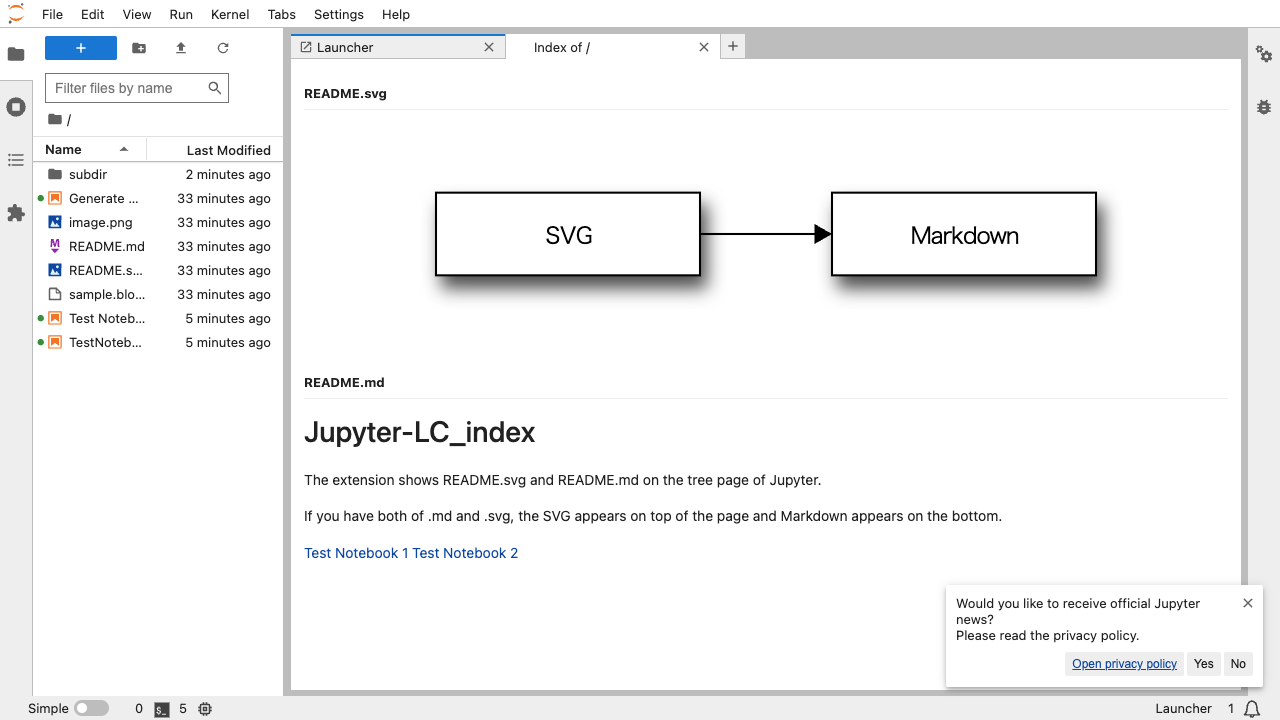

In [51]:
lab_page = None

async def _step(page):
    await page.goto(jupyterlab_url)

    # Wait for JupyterLab to load
    await expect(page.locator('#jp-main-dock-panel')).to_be_visible(timeout=transition_timeout)

    # Wait for file browser to be visible
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

    global lab_page
    lab_page = page

await run_pw(_step)

## Verify that Index tab is opened

Start epoch: 1763024224.8506272 seconds
Index tab is visible


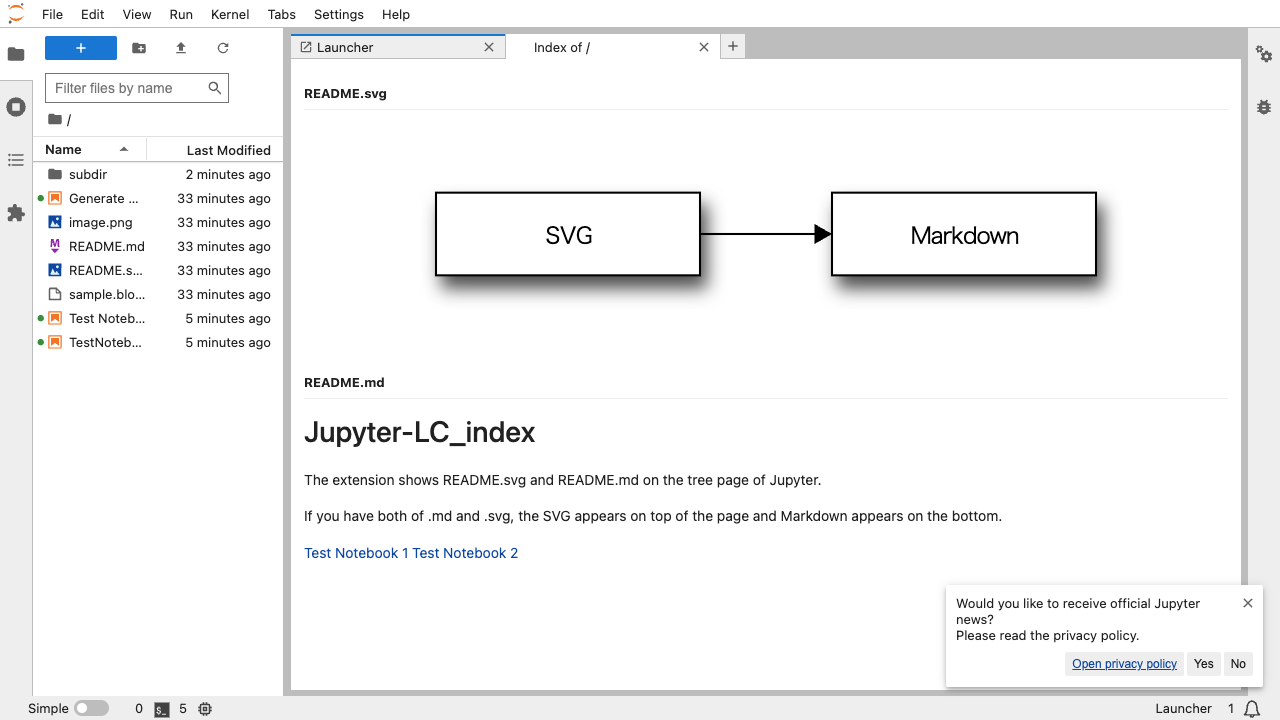

In [52]:
import re

async def _step(page):
    # Wait for Index tab to be visible (tab label is "Index of /")
    index_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and starts-with(text(), "Index of")]')
    await expect(index_tab).to_be_visible(timeout=transition_timeout)
    
    print("Index tab is visible")
    
    # Close any previously opened notebook tabs
    await asyncio.sleep(1)
    
    notebook_names = ['TestNotebook1.ipynb', 'Test Notebook2.ipynb', 'SubNotebook1.ipynb', 'Sub Notebook2.ipynb']
    for notebook_name in notebook_names:
        notebook_tab = page.locator(f'//*[contains(@class, "lm-TabBar-tabLabel") and text()="{notebook_name}"]')
        if await notebook_tab.is_visible():
            # Click on the tab to make it active
            await notebook_tab.click()
            await expect(notebook_tab.locator('..')).to_have_class(re.compile(r'lm-mod-current'))
            
            # Click the close icon
            close_icon = notebook_tab.locator('..').locator('.lm-TabBar-tabCloseIcon')
            await close_icon.click()
            
            # Wait for potential Discard dialog
            await asyncio.sleep(0.5)
            
            # Check if Discard button appears and click it
            discard_button = page.locator('//*[@class="jp-Dialog-buttonLabel" and text()="Discard"]')
            if await discard_button.is_visible():
                await discard_button.click()
                print(f"Clicked Discard button for {notebook_name}")
            
            # Wait for the tab to disappear
            await expect(notebook_tab).not_to_be_visible(timeout=transition_timeout)
            print(f"Closed previously opened {notebook_name}")

await run_pw(_step)

## Click on Index tab and verify content

Start epoch: 1763024226.3143868 seconds
Index widget is visible
README.svg content (img tag) is visible in Index widget
Found 2 label widgets in Index
TestNotebook1.ipynb opened successfully from root Index


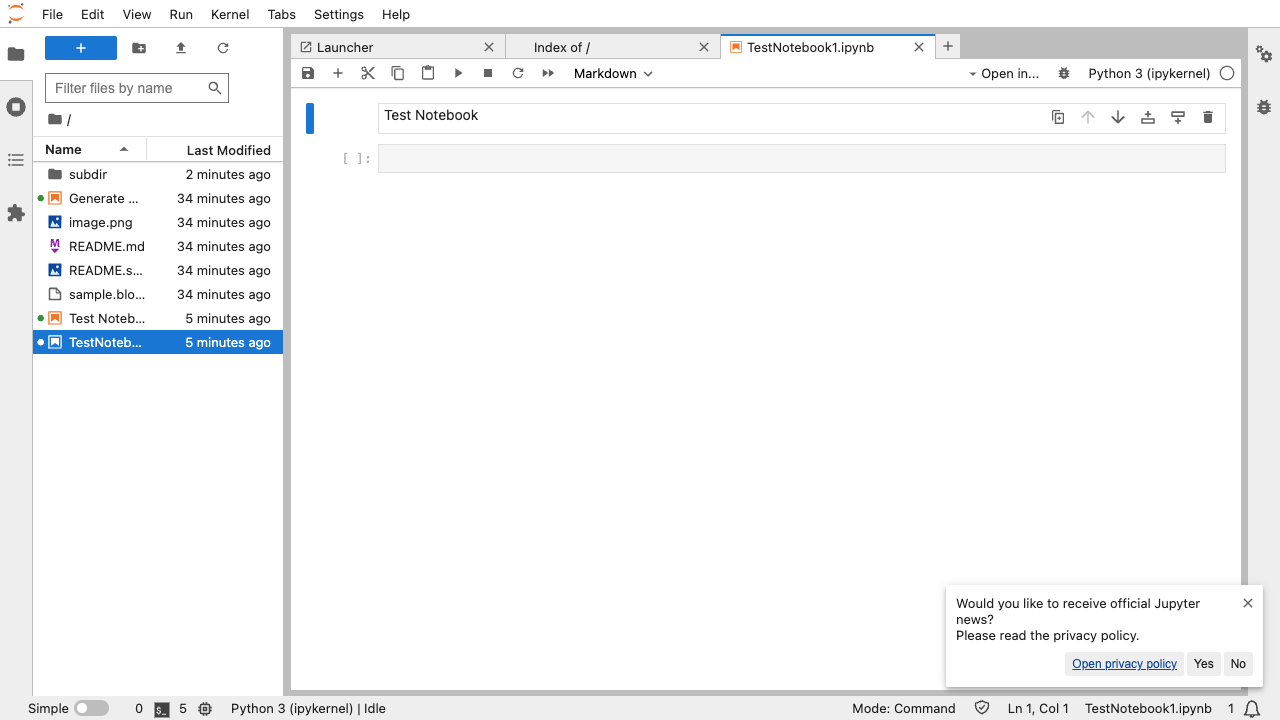

In [53]:
async def _step(page):
    # Click on Index tab
    index_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and starts-with(text(), "Index of")]')
    await index_tab.click()
    
    # Wait for Index widget to be visible
    await asyncio.sleep(1)
    
    # Verify that lc-index-widget is visible
    index_widget = page.locator('.lc-index-widget')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    print("Index widget is visible")
    
    # Verify that README.svg content is visible (SVG is embedded as img tag)
    img_content = index_widget.locator('img')
    await expect(img_content).to_be_visible(timeout=transition_timeout)
    
    print("README.svg content (img tag) is visible in Index widget")
    
    # Verify that label widgets are visible
    label_widgets = page.locator('.lc-index-widget-label')
    label_count = await label_widgets.count()
    assert label_count >= 1, f"Expected at least 1 label widget, got {label_count}"
    
    print(f"Found {label_count} label widgets in Index")
    
    # Click on Test Notebook 1 link in the Index content
    test_notebook_link = index_widget.locator('a:has-text("Test Notebook 1")')
    await expect(test_notebook_link).to_be_visible(timeout=transition_timeout)
    await test_notebook_link.click()
    
    # Wait for notebook to open
    await asyncio.sleep(2)
    
    # Verify that TestNotebook1.ipynb tab is now visible
    notebook_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and text()="TestNotebook1.ipynb"]')
    await expect(notebook_tab).to_be_visible(timeout=transition_timeout)
    
    print("TestNotebook1.ipynb opened successfully from root Index")

await run_pw(_step)

## Navigate to subdirectory and verify Index updates

Start epoch: 1763024229.9904199 seconds
Index tab updated with subdirectory content
SubNotebook1.ipynb opened successfully from subdir Index


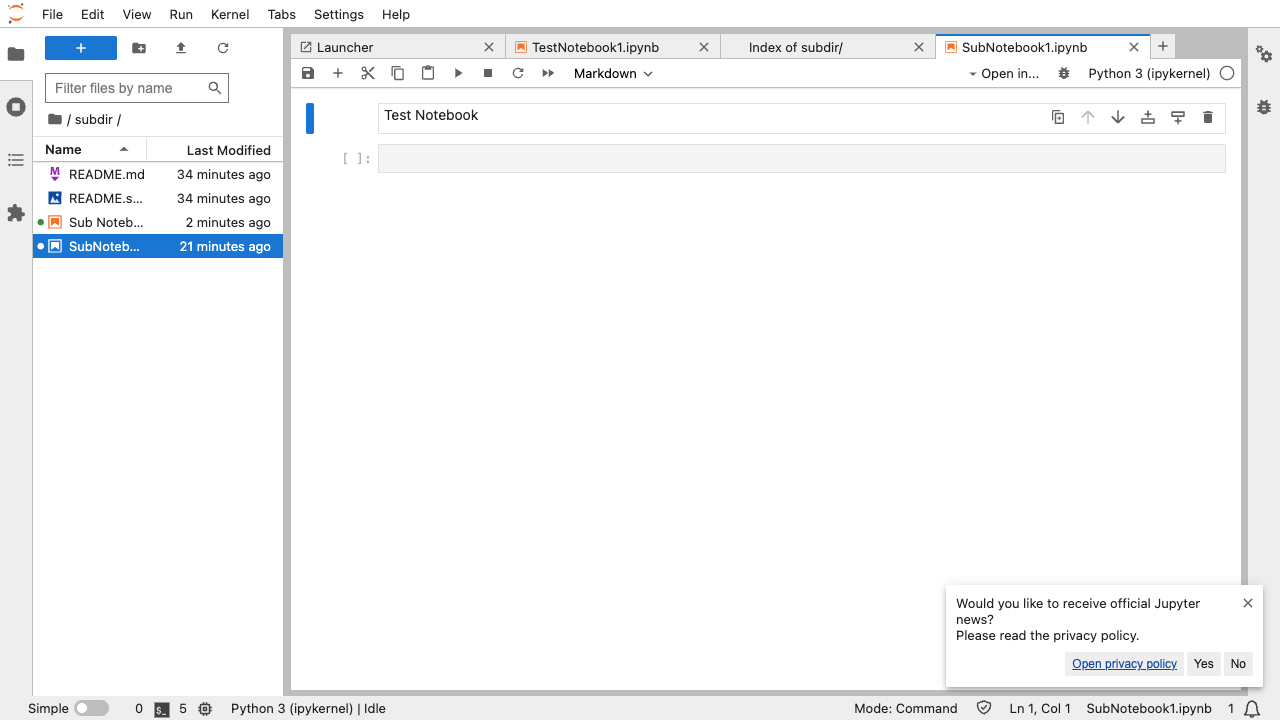

In [54]:
async def _step(page):
    # Double-click on subdir to navigate into it
    subdir = jupyterlab.get_file_browser_item_locator(page, 'subdir')
    await expect(subdir).to_be_visible(timeout=transition_timeout)
    await subdir.dblclick()
    
    # Wait for navigation to complete
    await asyncio.sleep(2)
    
    # Verify that Index tab still exists (now showing "Index of subdir/")
    index_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and starts-with(text(), "Index of")]')
    await expect(index_tab).to_be_visible(timeout=transition_timeout)
    
    # Click on Index tab
    await index_tab.click()
    await asyncio.sleep(1)
    
    # Verify that subdirectory's README content is displayed
    index_widget = page.locator('.lc-index-widget')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    img_content = index_widget.locator('img')
    await expect(img_content).to_be_visible(timeout=transition_timeout)
    
    print("Index tab updated with subdirectory content")
    
    # Click on Test Notebook 1 link in the subdir Index content
    sub_notebook_link = index_widget.locator('a:has-text("Test Notebook 1")')
    await expect(sub_notebook_link).to_be_visible(timeout=transition_timeout)
    await sub_notebook_link.click()
    
    # Wait for notebook to open
    await asyncio.sleep(2)
    
    # Verify that SubNotebook1.ipynb tab is now visible
    notebook_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and text()="SubNotebook1.ipynb"]')
    await expect(notebook_tab).to_be_visible(timeout=transition_timeout)
    
    print("SubNotebook1.ipynb opened successfully from subdir Index")

await run_pw(_step)

## Navigate back to root and verify Index updates again

Start epoch: 1763024235.531873 seconds
Index tab updated back to root directory content
Test Notebook2.ipynb opened successfully from root Index after navigating back


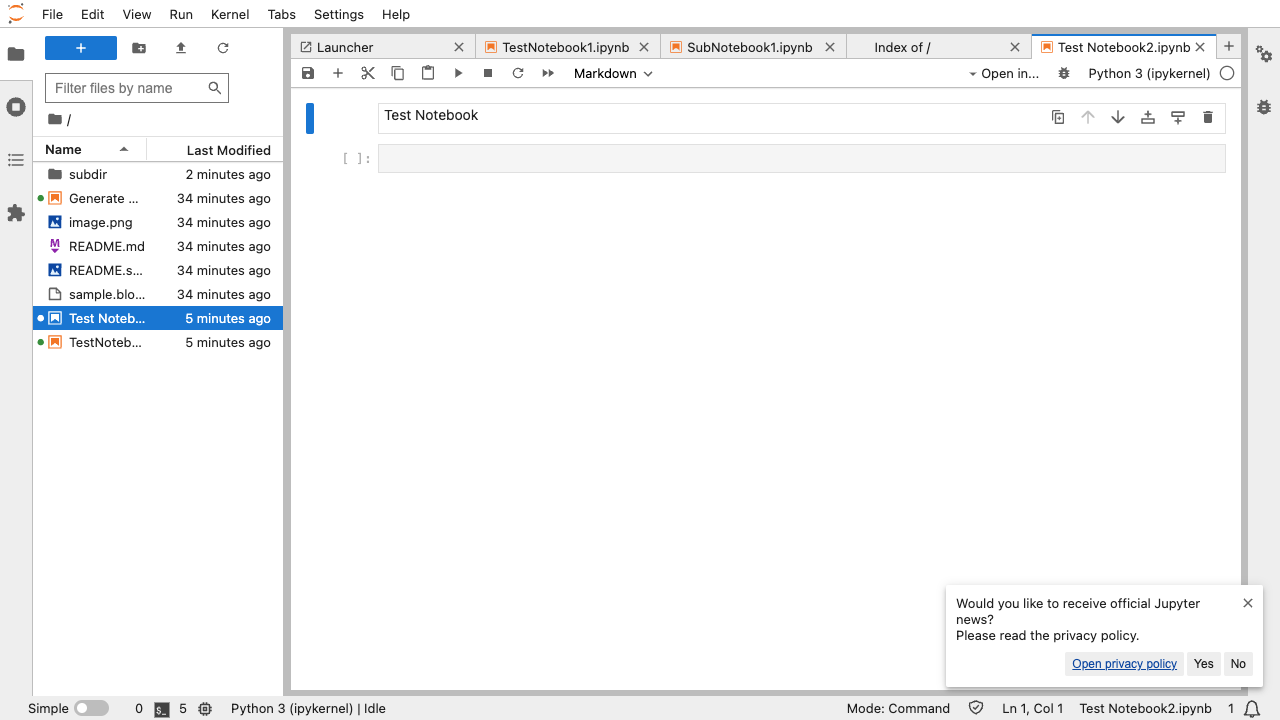

In [55]:
async def _step(page):
    # Click on breadcrumb to go back to root
    breadcrumb = page.locator('.jp-FileBrowser-crumbs').locator('span').first
    await breadcrumb.click()
    
    # Wait for navigation to complete
    await asyncio.sleep(2)
    
    # Click on Index tab
    index_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and starts-with(text(), "Index of")]')
    await index_tab.click()
    await asyncio.sleep(1)
    
    # Verify that root README content is displayed again
    index_widget = page.locator('.lc-index-widget')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    img_content = index_widget.locator('img')
    await expect(img_content).to_be_visible(timeout=transition_timeout)
    
    label_widgets = page.locator('.lc-index-widget-label')
    label_count = await label_widgets.count()
    assert label_count >= 1, f"Expected at least 1 label widget, got {label_count}"
    
    print("Index tab updated back to root directory content")
    
    # Click on Test Notebook 2 link to verify root directory link works
    test_notebook_link = index_widget.locator('a:has-text("Test Notebook 2")')
    await expect(test_notebook_link).to_be_visible(timeout=transition_timeout)
    await test_notebook_link.click()
    
    # Wait for notebook to open
    await asyncio.sleep(2)
    
    # Verify that Test Notebook2.ipynb tab is visible (confirming we're back at root, not subdir)
    notebook_tab = page.locator('//*[contains(@class, "lm-TabBar-tabLabel") and text()="Test Notebook2.ipynb"]')
    await expect(notebook_tab).to_be_visible(timeout=transition_timeout)
    
    print("Test Notebook2.ipynb opened successfully from root Index after navigating back")

await run_pw(_step)

## Clean up

In [56]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxpud4ddf/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxpud4ddf/har.zip
Console log: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxpud4ddf/console.log


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/Jupyter-LC_index/ui-tests/e2e-notebook/notebooks/scripts/playwright.py", line 254, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp01ofyxua/videos/bfb850554da368aa5ba688a22ec36085.webm'


In [57]:
!rm -fr {work_dir}